# **Notebook 02: Simulate DoA Estimation for Coprime Array**

This notebook demonstrates the simulation of Direction of Arrival (DoA) estimation using a Sparse Coprime Array with large apparture (Specifically GICA Array Configuration) and the MUSIC (Multiple Signal Classification) algorithm for estimating the Direction of Arrival.

## **1. Environment Setup and Parameters**
We begin by importing necessary libraries and setting core simulation parameters such as the number of samples, sampling frequency, and true source angles.

In [820]:
import sys
sys.path.insert(0, '/home/sajid/Work/DL-DoA')

In [821]:
import numpy as np
import matplotlib.pyplot as plt
from simulators.signal_simulator import generate_composite_radio_signals
from tools.covariance_matrix import array_signal_model, covariance_matrix
from tools.array_config import Coprime_Array
from tools.interpolators import CovarianceMatrixInterpolator
from tools.doa_algorithms import estimate_doa_music
from tools.metrics import calculate_robust_rmse

In [822]:
# Parameters
num_samples = 1000
fs = 2000
n = 2
angles = np.arange(-60, 60, 1)
doa_angles = sorted(np.unique(np.random.choice(angles, n)).tolist())
num_sources = len(doa_angles)

random_seed = None

print("Number of Souces:", num_sources)
print("Source Angles:", doa_angles)

Number of Souces: 2
Source Angles: [-57, -32]


## **2. Signal Generation**
Complex source signals are generated to simulate radio frequency emissions from five distinct sources.

In [823]:
# 1. Generate Complex Source Signals
signals, time_vector, _ = generate_composite_radio_signals(
    num_sources=num_sources,
    num_samples=num_samples,
    fs=fs,
    snr_db=10,
    random_seed=random_seed
)

#### **Visualizing Source Signals**
The absolute amplitude of each generated source signal is plotted over time.

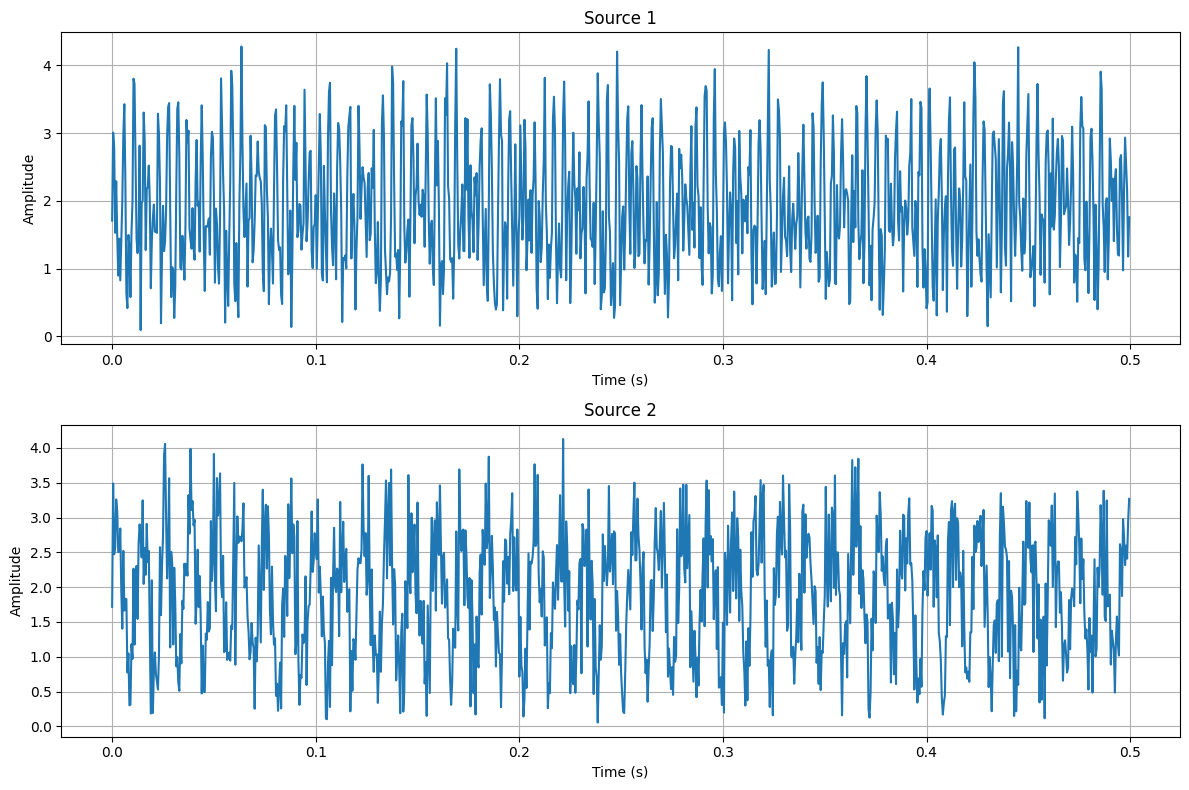

In [824]:
# Plot the generated signals in separate subplots
time_vector = np.arange(num_samples) / fs
plt.figure(figsize=(12, 8))
for i in range(num_sources):
    plt.subplot(num_sources, 1, i + 1)
    plt.plot(time_vector, np.abs(signals[i]))
    plt.title(f'Source {i + 1}')
    plt.xlabel('Time (s)')
    plt.ylabel('Amplitude')
    plt.grid()
plt.tight_layout()
plt.show()

## **3. Array Geometry and Received Signal**
A Uniform Linear Array (ULA) is configured with 16 sensors spaced at half-wavelength intervals ($d=0.5$).

In [825]:
# 2. Setup Coprime Array Geometry (ULA)
M = 3
N = 4
d = 0.5
array_config = Coprime_Array(M=M, N=N, d=d, model_type="GoldenRatio")
num_sensors = array_config.number_of_sensors
sensor_positions = array_config.sensor_positions
dof = array_config.dof
virtual_positions = array_config.virtual_positions
hole_positions = array_config.hole_positions

print("Number of Sensors:", num_sensors)
print("Degrees of Freedom (DoF):", dof)
print("Sensor Positions :", sensor_positions)
print("Virtual Sensor Positions :", virtual_positions)
print("Hole Positions :", hole_positions)

Number of Sensors: 11
Degrees of Freedom (DoF): 45
Sensor Positions : [0, 4, 5, 6, 7, 8, 12, 20, 26, 34, 45]
Virtual Sensor Positions : [ 0  1  2  3  4  5  6  7  8 11 12 13 14 15 16 18 19 20 21 22 25 26 27 28
 29 30 33 34 37 38 39 40 41 45]
Hole Positions : [ 9 10 17 23 24 31 32 35 36 42 43 44]


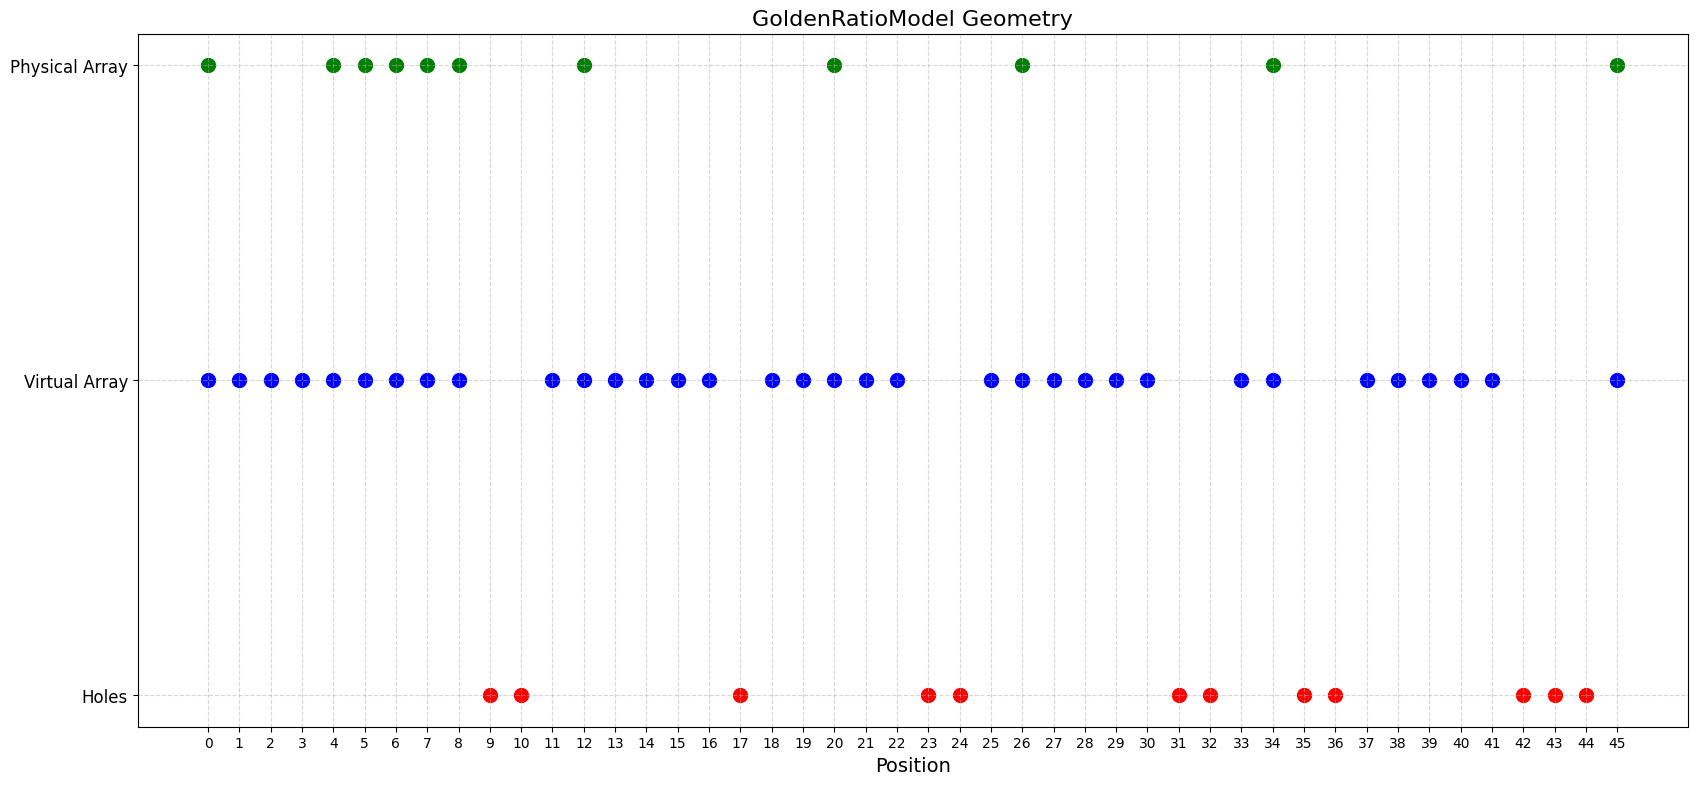

In [826]:
# Visualize the array geometry
array_config.visualize_array()

In [827]:
# 3. Generate Received Array Signals
sensor_snr = -5  # SNR in dB
n_snapshots = 1000

X, _, _ = array_signal_model(
    source_signals=signals,
    sensor_positions=virtual_positions,
    doa_angles=doa_angles,
    wavelength=1.0,
    snr_db=sensor_snr,
    n_snapshots=n_snapshots,
    random_seed=random_seed
)

print(f"Received signal shape: {X.shape}")

Received signal shape: (34, 1000)


## **4. Covariance Matrix Analysis**
The sample covariance matrix $R$ is computed from the received signal $X$ and visualized using a heatmap to show sensor correlations.

In [828]:
# 4. Compute Covariance Matrix
R = covariance_matrix(X)

print(f"Number of Virtual Sensors: {len(virtual_positions)}")
print(f"Number of Holes: {len(hole_positions)}")
print(f"Covariance matrix shape: {R.shape}")

Number of Virtual Sensors: 34
Number of Holes: 12
Covariance matrix shape: (34, 34)


## **5. Covariance Matrix Interpolation**
The goal is to map an observed sparse covariance matrix $\mathbf{R}_{obs} \in \mathbb{C}^{N \times N}$ (where $N=34$) to a full Toeplitz covariance matrix $\mathbf{R}_{full} \in \mathbb{C}^{M \times M}$ (where $M=46$).

In [829]:
interpolator = CovarianceMatrixInterpolator(
    R_obs=R,
    virtual_indices=virtual_positions,
    target_dof=dof
)

# Iterative Power Factorization to Interpolate Missing Covariance Entries
R_interpolated = interpolator.solve_sbl()
print("Total Number of Virtual Sensors:", dof+1)
print(f"Interpolated covariance matrix shape: {R_interpolated.shape}")

Total Number of Virtual Sensors: 46
Interpolated covariance matrix shape: (46, 46)


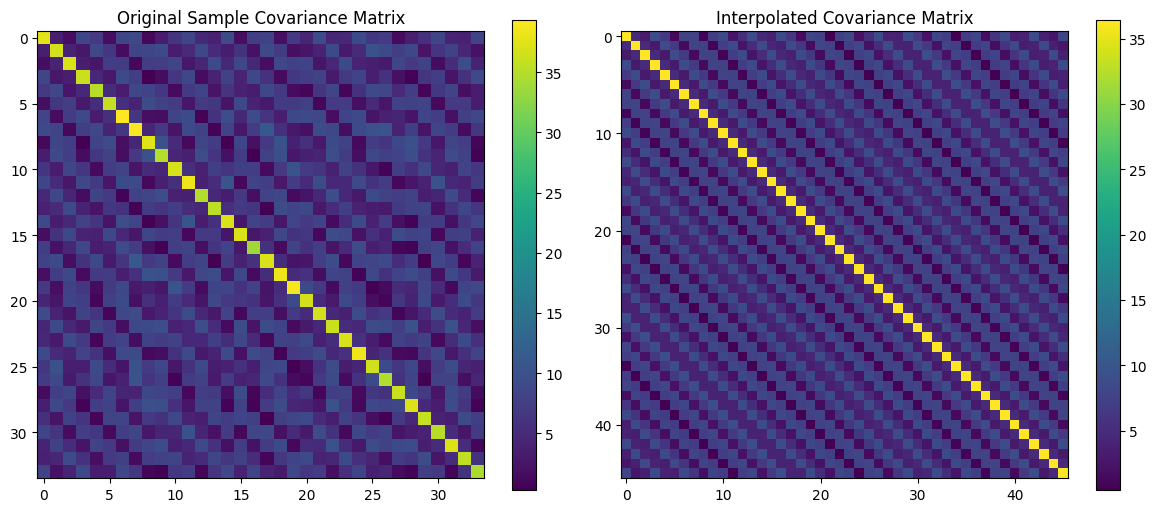

In [830]:
# Plot the original and interpolated covariance matrices
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.imshow(np.abs(R), cmap='viridis')
plt.title('Original Sample Covariance Matrix')
plt.colorbar()
plt.subplot(1, 2, 2)
plt.imshow(np.abs(R_interpolated), cmap='viridis')
plt.title('Interpolated Covariance Matrix')
plt.colorbar()
plt.tight_layout()
plt.show()

## **6. DoA Estimation using MUSIC**
The MUSIC algorithm scans the physical field of view from $-90^\circ$ to $90^\circ$ to estimate the incoming angles of the signals.

In [831]:
# 5. Estimate DOA
interpolated_virtual_positions = array_config.equivalent_uniform_array()
estimated_angles, spectrum, angle_grid = estimate_doa_music(
    Rxx=R_interpolated,
    num_sources=num_sources,
    sensor_positions=interpolated_virtual_positions,
    n_snapshots=n_snapshots,
    wavelength=1.0,
    scan_angles=np.linspace(-90, 90, 1801)
)

print("Estimation Complete!")

Estimation Complete!


#### **MUSIC Spectrum Plot**
The spectrum shows sharp peaks at the estimated angles, aligning closely with the actual DoA markers.

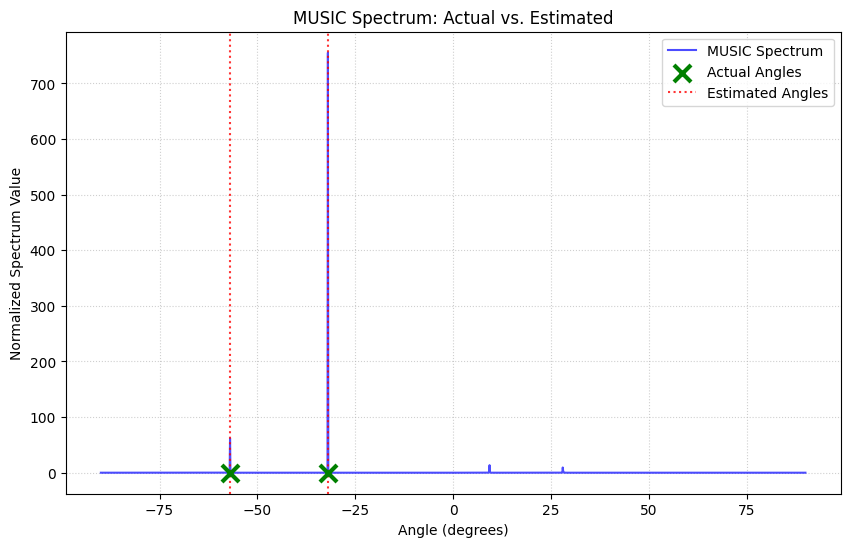

In [832]:
plt.figure(figsize=(10, 6))
plt.plot(angle_grid, spectrum, label='MUSIC Spectrum', color='b', alpha=0.7)

# Mark actual DOA angles to compare with estimated angles
for i, angle in enumerate(doa_angles):
    label = 'Actual Angles' if i == 0 else ""
    plt.scatter(angle, 0, color='g', marker='x', s=150, 
                linewidths=3, label=label, zorder=6)

# Mark estimated DOA angles
for i, angle in enumerate(estimated_angles):
    label = 'Estimated Angles' if i == 0 else ""
    plt.axvline(x=angle, color='r', linestyle=':', linewidth=1.5, 
                label=label, zorder=4, alpha=0.8)

plt.title('MUSIC Spectrum: Actual vs. Estimated')
plt.xlabel('Angle (degrees)')
plt.ylabel('Normalized Spectrum Value')
plt.legend(loc='upper right')
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

## **7. Performance Evaluation**
The accuracy of the estimation is measured using the Root Mean Square Error (RMSE).

In [833]:
# RMSE Calculation
rmse = calculate_robust_rmse(estimated_angles, doa_angles)

print(f"Number of sources        : {num_sources}")
print(f"Number of Estimated DOAs : {len(estimated_angles)}\n")

print(f"True DOA angles     : {doa_angles}")
print(f"Estimated DOA angles: {estimated_angles.tolist()}\n")

print(f"Robust RMSE between estimated and true DOA angles: {rmse:.2f} degrees")

Number of sources        : 2
Number of Estimated DOAs : 2

True DOA angles     : [-57, -32]
Estimated DOA angles: [-57.0, -32.0]

Robust RMSE between estimated and true DOA angles: 0.00 degrees
